単語ベクトルモデルを読み込んでいます...
モデルの読み込み完了。
国名リストファイル 'Book1.csv' を読み込んでいます...
209個のユニークな国名をファイルから抽出しました。
  (情報) 'American Samoa' はモデルの語彙にないためスキップします。
  (情報) 'Antigua and Barbuda' はモデルの語彙にないためスキップします。
  (情報) 'Bolivia, Plurinational State of' はモデルの語彙にないためスキップします。
  (情報) 'Bosnia and Herzegovina' はモデルの語彙にないためスキップします。
  (情報) 'Brunei Darussalam' はモデルの語彙にないためスキップします。
  (情報) 'Burkina Faso' はモデルの語彙にないためスキップします。
  (情報) 'Cape Verde' はモデルの語彙にないためスキップします。
  (情報) 'Cayman Islands' はモデルの語彙にないためスキップします。
  (情報) 'Central African Republic' はモデルの語彙にないためスキップします。
  (情報) 'Costa Rica' はモデルの語彙にないためスキップします。
  (情報) 'Côte d'Ivoire' はモデルの語彙にないためスキップします。
  (情報) 'Dominican Republic' はモデルの語彙にないためスキップします。
  (情報) 'El Salvador' はモデルの語彙にないためスキップします。
  (情報) 'Eswatini' はモデルの語彙にないためスキップします。
  (情報) 'Faroe Islands' はモデルの語彙にないためスキップします。
  (情報) 'French Guiana' はモデルの語彙にないためスキップします。
  (情報) 'French Polynesia' はモデルの語彙にないためスキップします。
  (情報) 'Guinea-Bissau' はモデルの語彙にないためスキップします。
  (情報) 'Hong Kong' はモデルの語彙にないためスキップします。
  (情報) 'Iran, Islamic Republ

c:\Users\eriya\anaconda3\envs\python-env\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


次元削減完了。
散布図を生成しています...
プロットウィンドウを表示します。


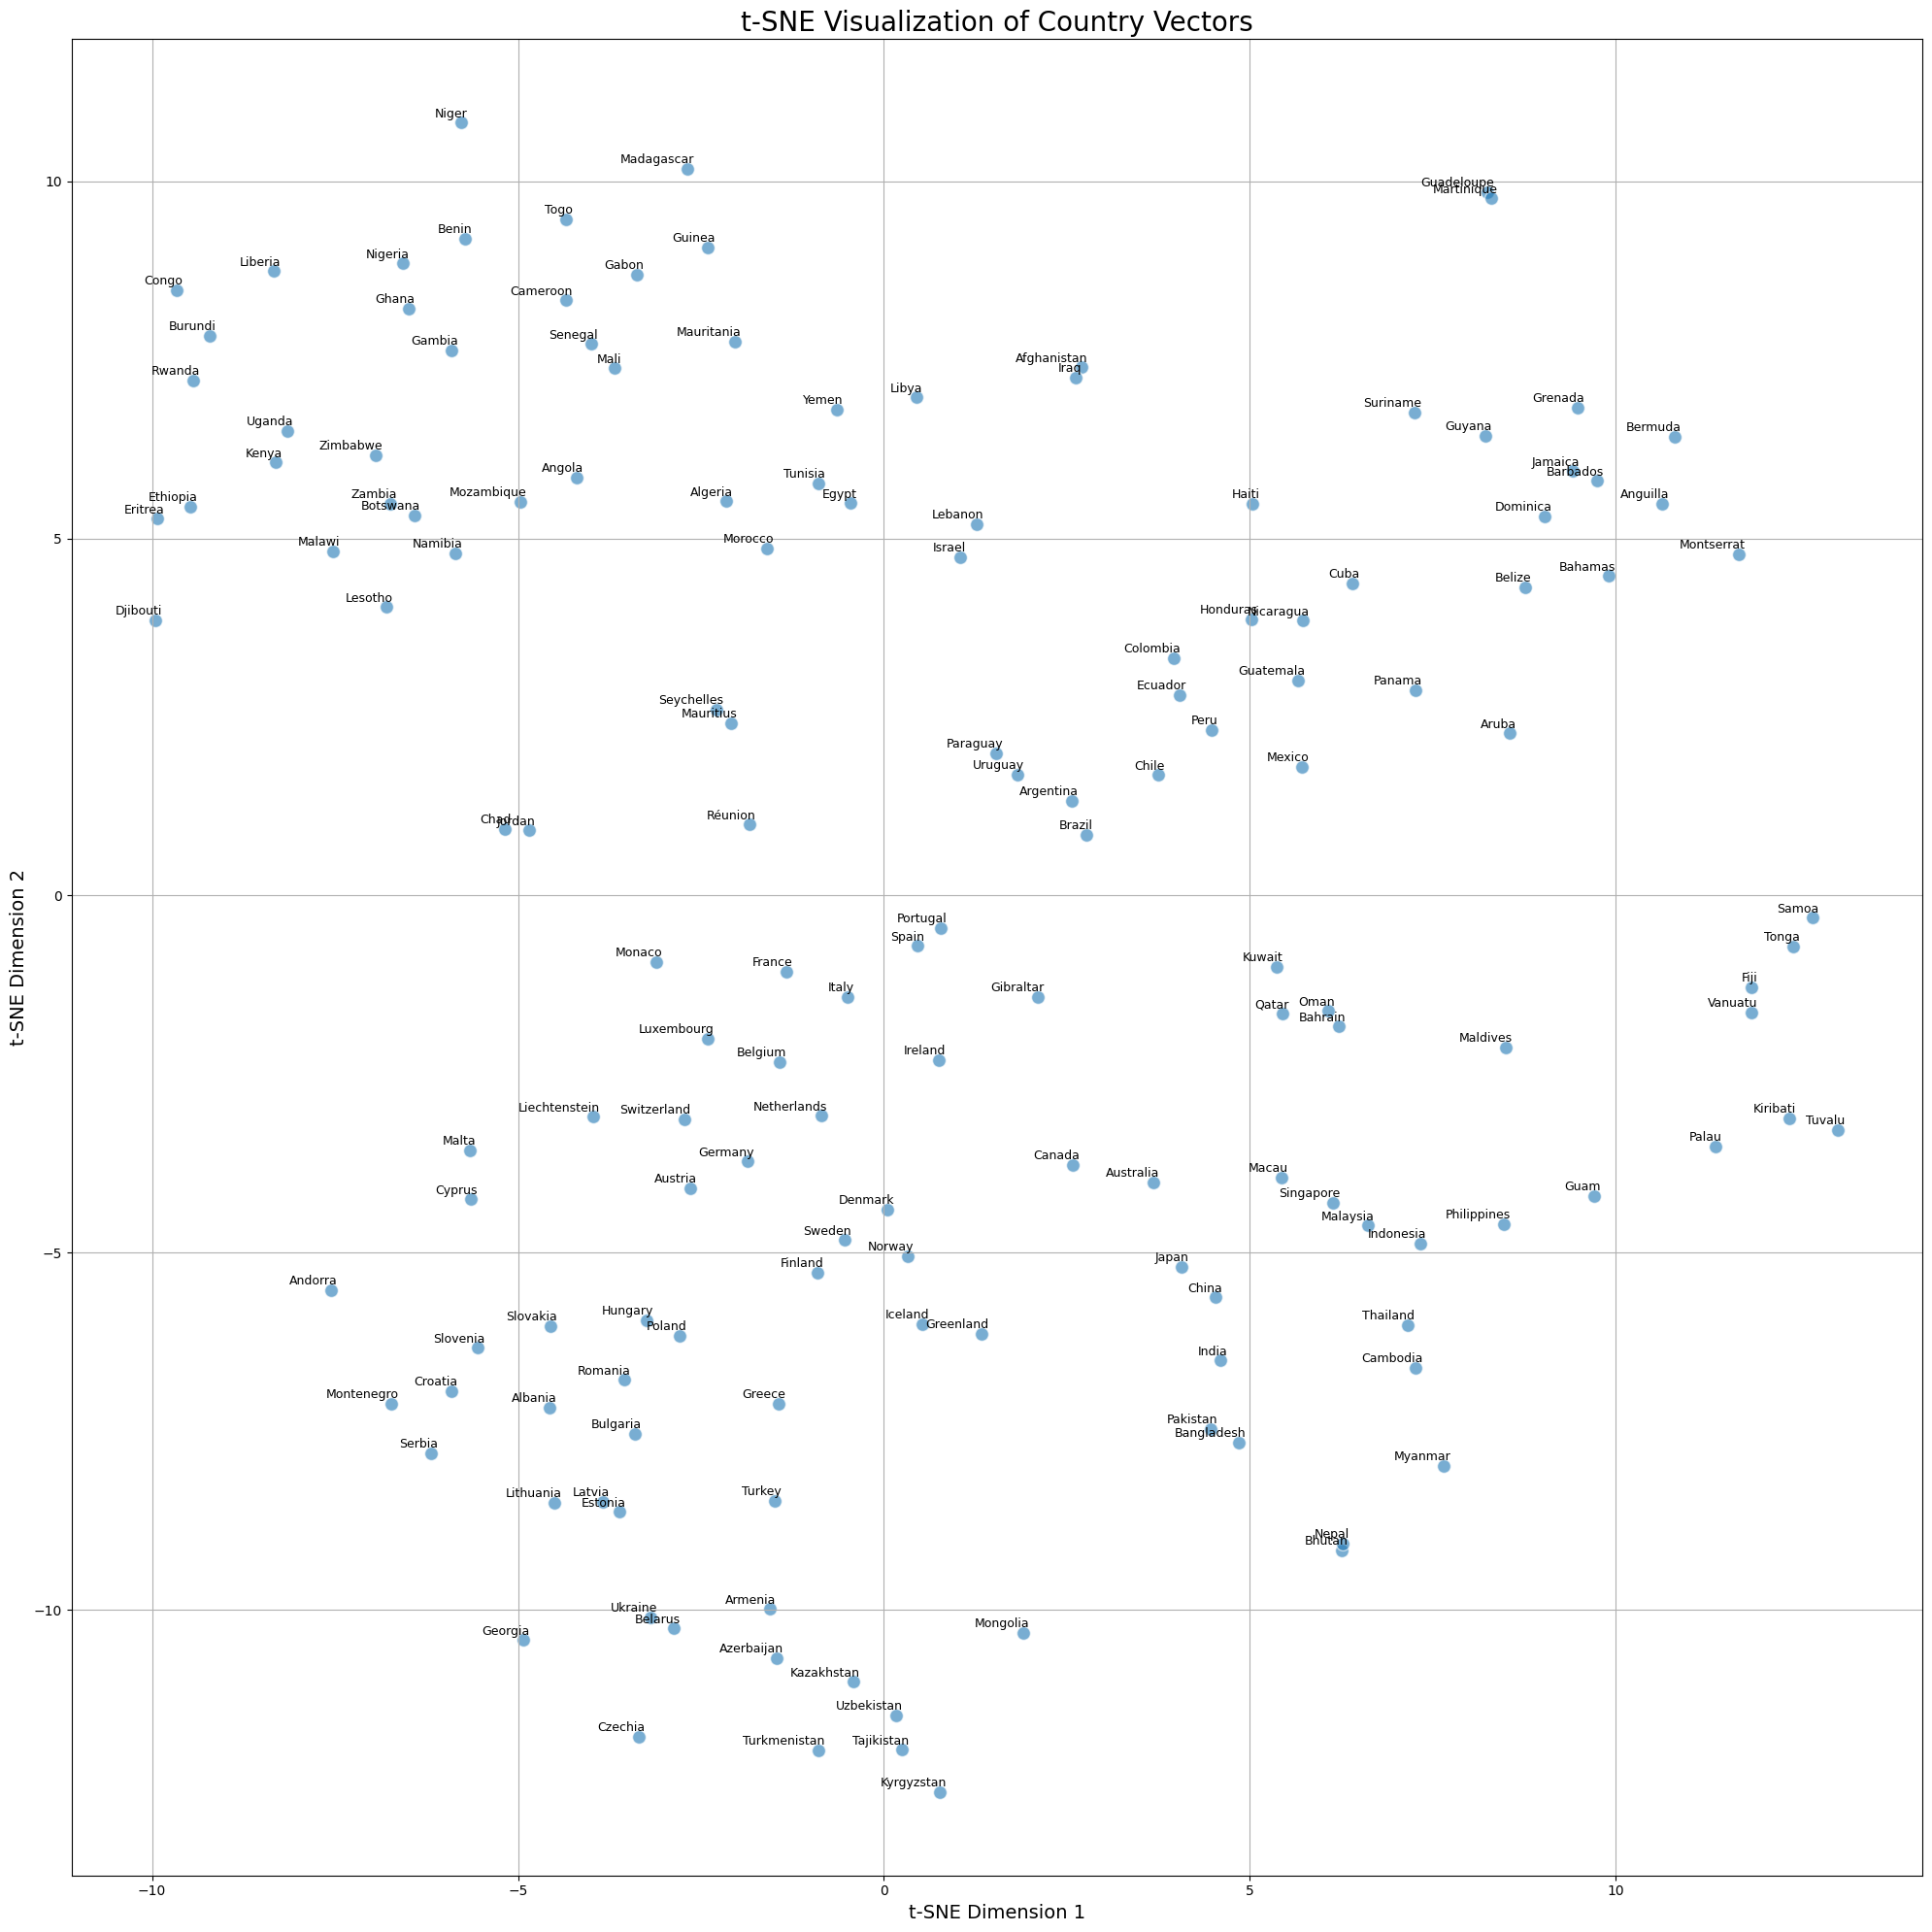

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gensim.models import KeyedVectors
from sklearn.manifold import TSNE

# --- ファイルパスの設定 ---
MODEL_FILE = "GoogleNews-vectors-negative300.bin.gz"
COUNTRY_LIST_FILE = "Book1.csv"

# --- 必要なファイルの存在をチェック ---
if not os.path.exists(MODEL_FILE):
    print(f"エラー: モデルファイルが見つかりません: {MODEL_FILE}")
elif not os.path.exists(COUNTRY_LIST_FILE):
    print(f"エラー: 国名リストファイルが見つかりません: {COUNTRY_LIST_FILE}")
else:
    try:
        # 1. モデルの読み込み
        print("単語ベクトルモデルを読み込んでいます...")
        model = KeyedVectors.load_word2vec_format(MODEL_FILE, binary=True)
        print("モデルの読み込み完了。")

        # 2. 国名リストの抽出 (Book1.csvから)
        print(f"国名リストファイル '{COUNTRY_LIST_FILE}' を読み込んでいます...")
        df = pd.read_csv(COUNTRY_LIST_FILE, header=None, on_bad_lines='skip')
        country_names = df[0].str.strip().dropna().unique().tolist()
        print(f"{len(country_names)}個のユニークな国名をファイルから抽出しました。")

        # 3. モデルに存在する国名の単語ベクトルを抽出
        country_vectors = []
        valid_country_names = []
        for country in sorted(country_names):
            if country in model:
                country_vectors.append(model[country])
                valid_country_names.append(country)
            else:
                print(f"  (情報) '{country}' はモデルの語彙にないためスキップします。")

        X = np.array(country_vectors)
        print(f"\nモデルの語彙に存在する{len(valid_country_names)}個の国名ベクトルを抽出しました。")

        if len(valid_country_names) < 2:
            print("エラー: 可視化するには有効な国が2カ国以上必要です。")
        else:
            # 4. t-SNEによる次元削減
            print("t-SNEによる次元削減を実行中... (時間がかかる場合があります)")
            tsne = TSNE(
                n_components=2,      # 2次元に削減
                perplexity=30.0,     # データ点の近傍の数を調整するパラメータ。5-50が一般的。
                n_iter=1000,         # 最適化の反復回数
                random_state=42      # 結果を固定するための乱数シード
            )
            vectors_2d = tsne.fit_transform(X)
            print("次元削減完了。")

            # 5. 散布図として可視化
            print("散布図を生成しています...")
            plt.figure(figsize=(20, 20)) # プロットサイズを大きくする

            # 散布図を描画
            plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], alpha=0.6, edgecolors='w', s=100)

            # 各点に国名ラベルを付ける
            for i, country in enumerate(valid_country_names):
                plt.annotate(
                    country,
                    xy=(vectors_2d[i, 0], vectors_2d[i, 1]),
                    xytext=(5, 2),
                    textcoords='offset points',
                    ha='right',
                    va='bottom',
                    fontsize=9
                )
            
            plt.title('t-SNE Visualization of Country Vectors', fontsize=20)
            plt.xlabel('t-SNE Dimension 1', fontsize=14)
            plt.ylabel('t-SNE Dimension 2', fontsize=14)
            plt.grid(True)
            plt.tight_layout()
            print("プロットウィンドウを表示します。")
            plt.show()

    except Exception as e:
        print(f"処理中に予期せぬエラーが発生しました: {e}")